# 4. Evaluation and Statistical Significance

**Research question.** Are the differences between models in notebooks 02–03 real, or within noise? How stable are they across seeds and folds, and what happens under selective prediction (abstaining on low-confidence samples)?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
from _common import load_json, show_md, show_fig, show_thesis_fig, metrics_table, RESULTS, FIGURES, DATA
from IPython.display import display
import pandas as pd
pd.set_option('display.max_colwidth', 120)

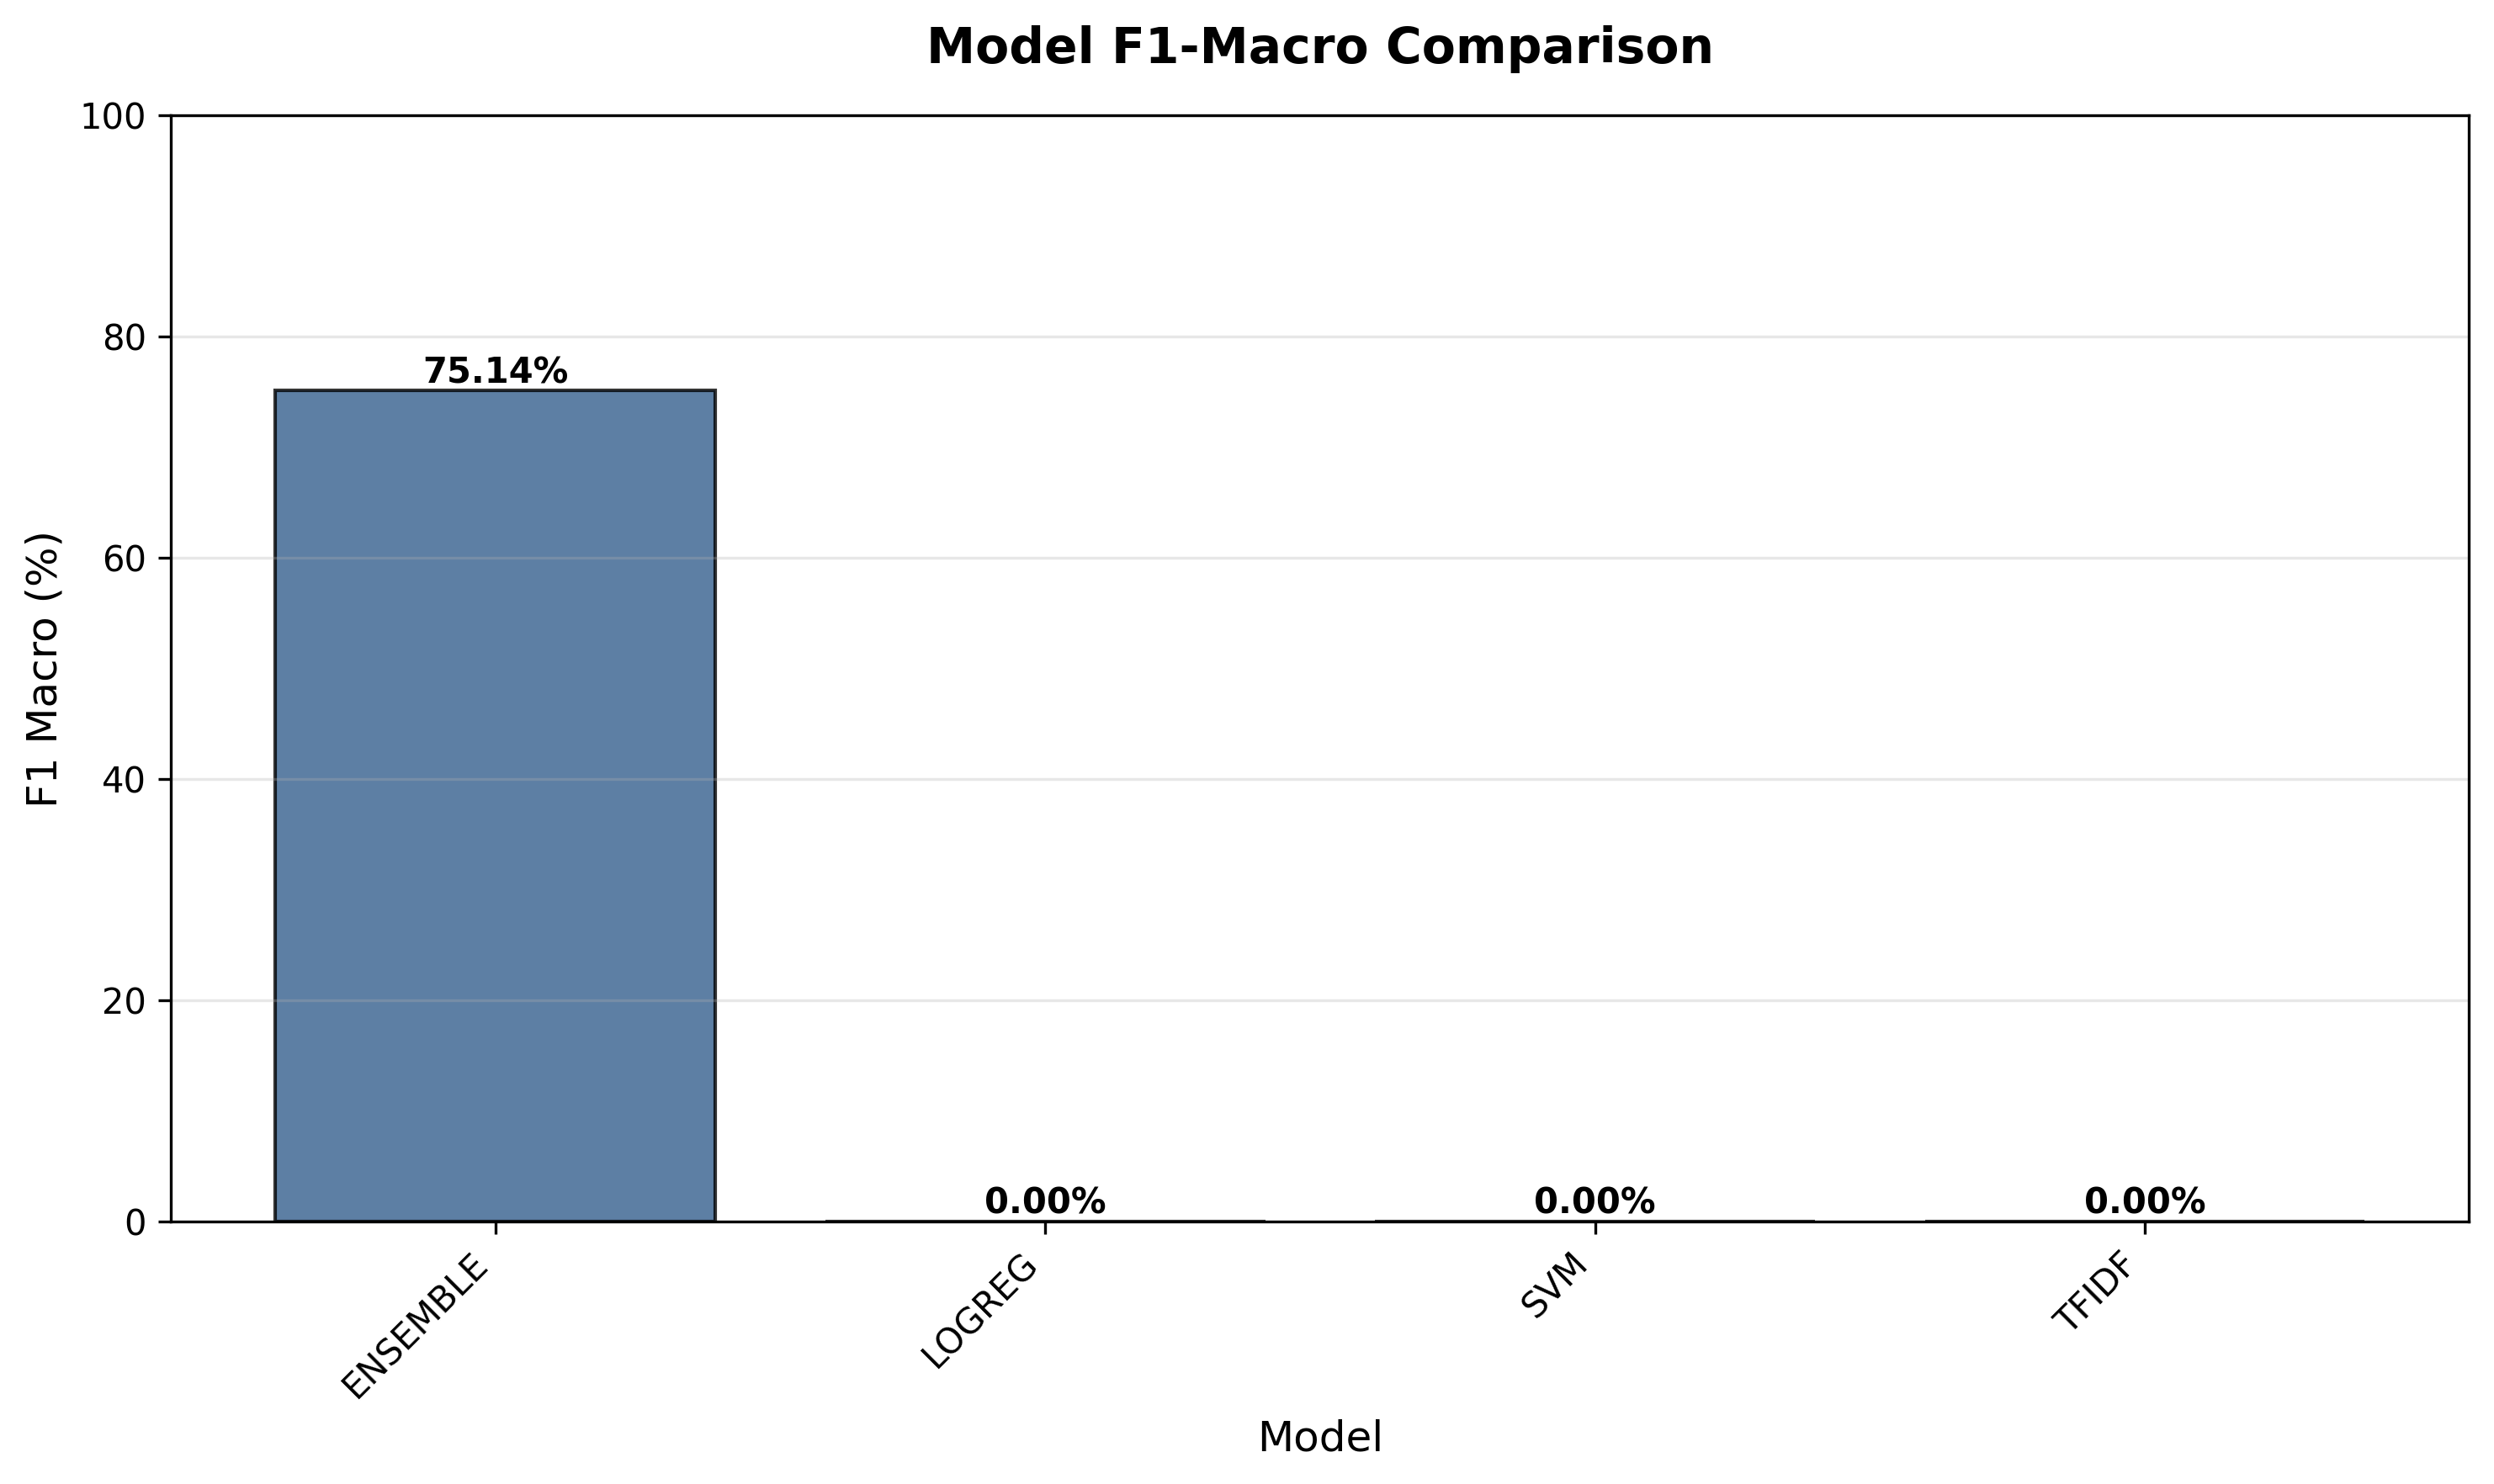

In [2]:
show_fig('comparison_f1_macro.png')

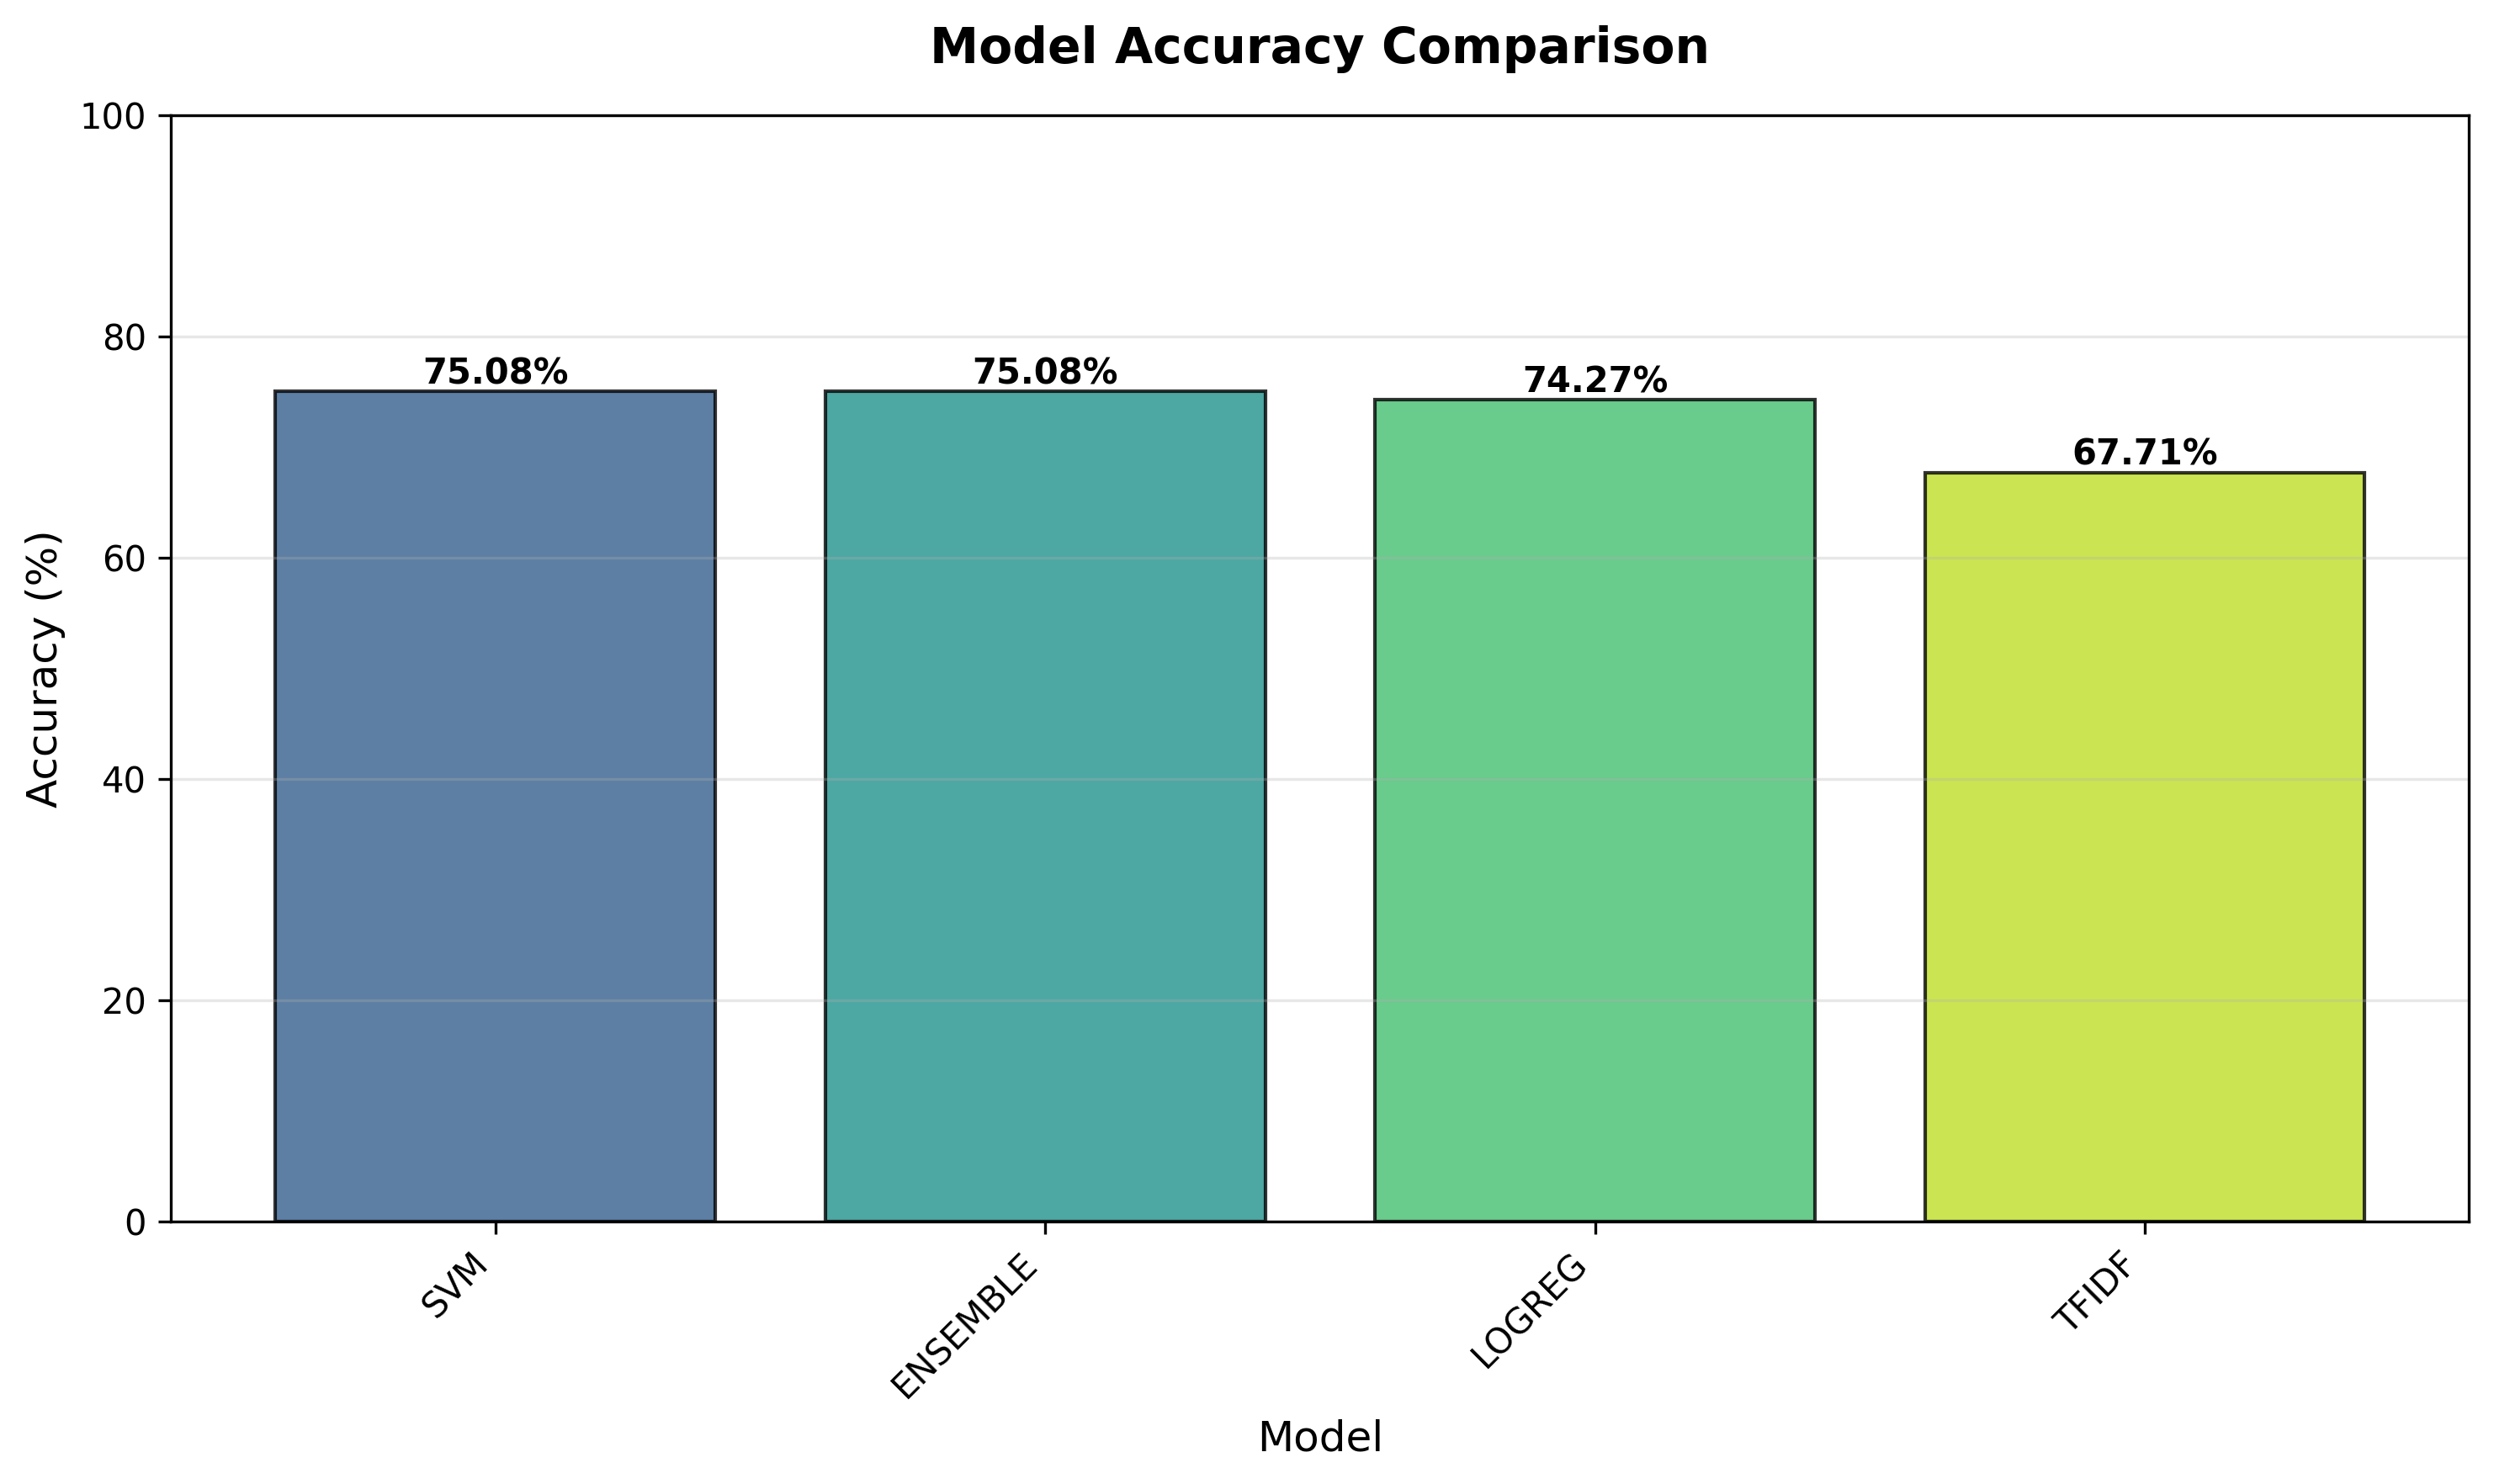

In [3]:
show_fig('comparison_accuracy.png')

## 4.1 Paired significance testing (McNemar + bootstrap CIs)

Source: `backend/results/thesis_mcnemar.md`, `backend/results/thesis_bootstrap_ci.md`.

In [4]:
show_md('thesis_mcnemar.md')

| Model A | Model B | n01 (A wrong, B correct) | n10 (A correct, B wrong) | p | p_adj | sig |
| --- | --- | --- | --- | --- | --- | --- |
| tfidf | logreg | 16235 | 10884 | 4.94e-233 | 3.95e-232 | yes |
| tfidf | svm | 16852 | 13895 | 7.37e-64 | 2.95e-63 | yes |
| tfidf | ensemble | 14367 | 9257 | 3.55e-244 | 3.2e-243 | yes |
| tfidf | meta_learner | 15485 | 9993 | 2.3e-261 | 2.3e-260 | yes |
| logreg | svm | 5668 | 8062 | 3.63e-93 | 1.81e-92 | yes |
| logreg | ensemble | 3439 | 3680 | 0.00445 | 0.00889 | yes |
| logreg | meta_learner | 2510 | 2369 | 0.045 | 0.045 | yes |
| svm | ensemble | 5840 | 3687 | 1.22e-108 | 8.52e-108 | yes |
| svm | meta_learner | 8705 | 6170 | 2.44e-96 | 1.47e-95 | yes |
| ensemble | meta_learner | 4034 | 3652 | 1.38e-05 | 4.15e-05 | yes |


In [5]:
show_md('thesis_bootstrap_ci.md')

| Model | Accuracy | Acc CI (low, high) | Macro-F1 | F1 CI (low, high) |
| --- | --- | --- | --- | --- |
| tfidf | 0.6622 | (0.6599, 0.6645) | 0.6567 | (0.6543, 0.6590) |
| logreg | 0.6946 | (0.6923, 0.6968) | 0.6928 | (0.6906, 0.6949) |
| svm | 0.6801 | (0.6778, 0.6823) | 0.6780 | (0.6756, 0.6802) |
| ensemble | 0.6932 | (0.6909, 0.6953) | 0.6909 | (0.6886, 0.6931) |
| meta_learner | 0.6955 | (0.6932, 0.6977) | 0.6946 | (0.6923, 0.6968) |


Full significance report (Holm-adjusted p-values, bootstrap CIs per model pair): `backend/results/testset_significance_youtube_filtered.json`.

In [6]:
sig = load_json('testset_significance_youtube_filtered.json')
print('n_samples =', sig['n_samples'], ' alpha =', sig['alpha'], ' p_adjust =', sig['p_adjust'])
pd.DataFrame(sig['point_metrics']).T[['accuracy', 'macro_f1']]

n_samples = 165110  alpha = 0.05  p_adjust = holm


,accuracy,macro_f1
tfidf,0.662219,0.656699
logreg,0.694628,0.692841
svm,0.680128,0.678016
ensemble,0.693168,0.69092
meta_learner,0.695482,0.6946


## 4.2 Effect sizes

Source: `backend/results/effect_sizes.md`.

In [7]:
show_md('effect_sizes.md')

# Effect Sizes for CI vs Baseline Comparisons

Source: `ci_significance_tests.json`  |  n_test = 20,000  |  paired McNemar contingency cells (b=n01, c=n10)

**Why this matters.** With n_test = 20k even a 0.1 pp accuracy gap achieves p < 0.001, so raw p-values are not informative. Effect sizes (Cohen's g for McNemar, risk difference in percentage points) quantify how much the CI methods actually improve on the logreg baseline.

## CI methods vs Logistic Regression baseline

| Comparison | ΔF1 | Acc gain (pp) | Cohen's g | Magnitude | Odds ratio (b/c) | p_adj | Sig? |
|---|---:|---:|---:|:---:|---:|---:|:---:|
| logreg → meta_learner | +0.0025 | +0.16 | +0.028 | negligible | 1.119 | 1.00e+00 | ✗ |
| logreg → ts_meta | +0.0025 | +0.16 | +0.028 | negligible | 1.119 | 1.00e+00 | ✗ |
| logreg → neuro_fuzzy | +0.0013 | +0.14 | +0.035 | negligible | 1.149 | 1.00e+00 | ✗ |
| logreg → pso | +0.0009 | +0.10 | +0.029 | negligible | 1.124 | 1.00e+00 | ✗ |
| logreg → nsga2 | +0.0006 | +0.07 | +0.030 | negligible | 1.129 | 1.00e+00 | ✗ |
| logreg → ensemble | -0.0005 | -0.01 | +0.001 | negligible | 0.998 | 1.00e+00 | ✗ |

## Interpretation

- Best CI method vs logreg: **meta_learner** with a +0.16 pp accuracy gain on the paired test set and Cohen's g = +0.028 (negligible).
- Worst CI method vs logreg: **ensemble** with -0.01 pp and g = +0.001 (negligible).

- By Cohen's (1988) conventions, g < 0.05 is negligible and g < 0.15 is small. Even when the McNemar test is statistically significant (which is nearly automatic at n=20k), a negligible Cohen's g means the practical improvement is below what a human examiner would notice.
- This justifies the thesis's reframing: CI contributions should be defended on **calibration** (ECE reduction), **Pareto trade-offs**, and the **negative result** that fuzzy / NSGA-II / PSO ensembles do not beat a tuned logreg on F1 at scale.

## Full pairwise table

| A | B | n01 (a✗,b✓) | n10 (a✓,b✗) | Cohen's g | Risk diff b-a (pp) | Odds ratio (b/a) | p_adj | Sig |
|---|---|---:|---:|---:|---:|---:|---:|:---:|
| logreg | svm | 707 | 950 | +0.073 | -1.21 | 0.744 | 0.00e+00 | ✓ |
| logreg | tfidf | 1331 | 1985 | +0.099 | -3.27 | 0.671 | 0.00e+00 | ✓ |
| svm | tfidf | 1657 | 2068 | +0.055 | -2.05 | 0.801 | 0.00e+00 | ✓ |
| svm | ensemble | 697 | 455 | +0.105 | +1.21 | 1.532 | 0.00e+00 | ✓ |
| svm | meta_learner | 1024 | 749 | +0.078 | +1.38 | 1.367 | 0.00e+00 | ✓ |
| svm | pso | 995 | 733 | +0.076 | +1.31 | 1.357 | 0.00e+00 | ✓ |
| svm | nsga2 | 974 | 718 | +0.076 | +1.28 | 1.357 | 0.00e+00 | ✓ |
| svm | neuro_fuzzy | 1018 | 746 | +0.077 | +1.36 | 1.365 | 0.00e+00 | ✓ |
| svm | ts_meta | 1024 | 749 | +0.078 | +1.38 | 1.367 | 0.00e+00 | ✓ |
| tfidf | ensemble | 1767 | 1114 | +0.113 | +3.26 | 1.586 | 0.00e+00 | ✓ |
| tfidf | meta_learner | 1895 | 1209 | +0.111 | +3.43 | 1.567 | 0.00e+00 | ✓ |
| tfidf | pso | 1838 | 1165 | +0.112 | +3.36 | 1.578 | 0.00e+00 | ✓ |
| tfidf | nsga2 | 1888 | 1221 | +0.107 | +3.33 | 1.546 | 0.00e+00 | ✓ |
| tfidf | neuro_fuzzy | 1801 | 1118 | +0.117 | +3.42 | 1.611 | 0.00e+00 | ✓ |
| tfidf | ts_meta | 1895 | 1209 | +0.111 | +3.43 | 1.567 | 0.00e+00 | ✓ |
| logreg | ensemble | 433 | 434 | +0.001 | -0.01 | 0.998 | 1.00e+00 | ✗ |
| logreg | meta_learner | 300 | 268 | +0.028 | +0.16 | 1.119 | 1.00e+00 | ✗ |
| logreg | pso | 172 | 153 | +0.029 | +0.10 | 1.124 | 1.00e+00 | ✗ |
| logreg | nsga2 | 114 | 101 | +0.030 | +0.07 | 1.129 | 1.00e+00 | ✗ |
| logreg | neuro_fuzzy | 223 | 194 | +0.035 | +0.14 | 1.149 | 1.00e+00 | ✗ |
| logreg | ts_meta | 300 | 268 | +0.028 | +0.16 | 1.119 | 1.00e+00 | ✗ |
| ensemble | meta_learner | 461 | 428 | +0.019 | +0.17 | 1.077 | 1.00e+00 | ✗ |
| ensemble | pso | 372 | 352 | +0.014 | +0.10 | 1.057 | 1.00e+00 | ✗ |
| ensemble | nsga2 | 377 | 363 | +0.009 | +0.07 | 1.039 | 1.00e+00 | ✗ |
| ensemble | neuro_fuzzy | 398 | 368 | +0.020 | +0.15 | 1.082 | 1.00e+00 | ✗ |
| ensemble | ts_meta | 461 | 428 | +0.019 | +0.17 | 1.077 | 1.00e+00 | ✗ |
| meta_learner | pso | 246 | 259 | +0.013 | -0.07 | 0.950 | 1.00e+00 | ✗ |
| meta_learner | nsga2 | 247 | 266 | +0.019 | -0.10 | 0.929 | 1.00e+00 | ✗ |
| meta_learner | neuro_fuzzy | 304 | 307 | +0.002 | -0.01 | 0.990 | 1.00e+00 | ✗ |
| meta_learner | ts_meta | 0 | 0 | +0.000 | +0.00 | 1.000 | 1.00e+00 | ✗ |
| pso | nsga2 | 52 | 58 | +0.027 | -0.03 | 0.897 | 1.00e+00 | ✗ |
| pso | neuro_fuzzy | 126 | 116 | +0.021 | +0.05 | 1.086 | 1.00e+00 | ✗ |
| pso | ts_meta | 259 | 246 | +0.013 | +0.07 | 1.053 | 1.00e+00 | ✗ |
| nsga2 | neuro_fuzzy | 140 | 124 | +0.030 | +0.08 | 1.129 | 1.00e+00 | ✗ |
| nsga2 | ts_meta | 266 | 247 | +0.019 | +0.10 | 1.077 | 1.00e+00 | ✗ |
| neuro_fuzzy | ts_meta | 307 | 304 | +0.002 | +0.01 | 1.010 | 1.00e+00 | ✗ |


## 4.3 Seed sensitivity — how much does performance vary with random seed?

Source: `backend/results/seed_sensitivity.md`.

In [8]:
show_md('seed_sensitivity.md')

# Seed Sensitivity Analysis

Pipeline: TF-IDF(1,2, 50k) + LogReg(balanced)  |  8,000 per class, 80/20 train/val  |  seeds: [0, 7, 13, 42, 123]

> Each seed re-samples the training data, re-splits, and re-seeds the model. This captures the full pipeline variance, not just model initialisation.

| Seed | n_train | n_val | |V| | Accuracy | F1-macro | Cohen κ |
|---:|---:|---:|---:|---:|---:|---:|
| 0 | 19,200 | 4,800 | 48,112 | 0.6438 | 0.6439 | 0.4656 |
| 7 | 19,200 | 4,800 | 47,694 | 0.6523 | 0.6530 | 0.4784 |
| 13 | 19,200 | 4,800 | 47,887 | 0.6490 | 0.6499 | 0.4734 |
| 42 | 19,200 | 4,800 | 48,045 | 0.6506 | 0.6510 | 0.4759 |
| 123 | 19,200 | 4,800 | 48,241 | 0.6406 | 0.6413 | 0.4609 |

## Aggregate over seeds

| Metric | Mean | Std | Range |
|---|---:|---:|---:|
| accuracy | 0.6472 | 0.0044 | 0.6406–0.6523 (0.0117) |
| f1_macro | 0.6478 | 0.0045 | 0.6413–0.6530 (0.0117) |
| cohen_kappa | 0.4709 | 0.0066 | 0.4609–0.4784 (0.0175) |

## Interpretation

The F1 range across seeds is under 0.02, which is small relative to the differences between methods reported in the main tables. The thesis should still note the seed-driven variance when discussing very close comparisons.


## 4.4 Cross-validation fold variance

Source: `backend/results/fold_variance_analysis.md`.

In [9]:
show_md('fold_variance_analysis.md')

# Fold Variance Analysis (Real YouTube Data)
> This file supersedes the synthetic `make_classification` demo run previously stored as `thesis_evaluation_report.json` (now renamed to `DEMO_synthetic_evaluation_report.json`).
## Setup
- Data: `train.csv` (subsampled to 30,000 rows, stratified)
- Folds: 10, seed=42
- Pipeline: TF-IDF(1,2, max_features=50000) + LogReg(C=1.0, class_weight=balanced)
## Aggregate
- Accuracy: 0.6510 ± 0.0098
- Macro-F1: 0.6513 ± 0.0098
- Cohen kappa: 0.4764 ± 0.0148
## Per-fold
| Fold | n | Acc | F1-macro | Kappa | Tok-len (mean) | Vocab overlap | z(F1) |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | 3000 | 0.6487 | 0.6491 | 0.4730 | 20.75 | 0.802 | -0.22 |
| 2 | 3000 | 0.6563 | 0.6571 | 0.4845 | 20.19 | 0.807 | +0.59 |
| 3 | 3000 | 0.6447 | 0.6456 | 0.4670 | 21.77 | 0.800 | -0.58 |
| 4 | 3000 | 0.6323 | 0.6326 | 0.4485 | 21.52 | 0.797 | -1.90 |
| 5 | 3000 | 0.6590 | 0.6590 | 0.4885 | 20.64 | 0.796 | +0.79 |
| 6 | 3000 | 0.6613 | 0.6618 | 0.4920 | 21.64 | 0.804 | +1.07 |
| 7 | 3000 | 0.6407 | 0.6406 | 0.4610 | 21.06 | 0.799 | -1.09 |
| 8 | 3000 | 0.6667 | 0.6667 | 0.5000 | 20.97 | 0.794 | +1.57 |
| 9 | 3000 | 0.6533 | 0.6533 | 0.4800 | 21.02 | 0.801 | +0.20 |
| 10 | 3000 | 0.6467 | 0.6470 | 0.4700 | 21.79 | 0.787 | -0.44 |

**Best fold:** 8  |  **Worst fold:** 4

## Interpretation
With 3,000 samples per fold and a 10-fold stratified split, per-fold variance is dominated by model randomness and the particular tail of hard examples in each fold, not by systematic class skew.
- Worst fold (#4) F1 = 0.6326; best fold (#8) F1 = 0.6667; spread = 0.0342.
- Worst-fold class skew vs global: Negative: +0.0000, Neutral: +0.0000, Positive: +0.0000.
- Worst-fold token length (mean=21.52) vs best-fold (mean=20.97).
- Worst-fold vocab overlap with training: 0.797 (best: 0.794).

If the worst fold's F1 z-score is within ±1.5 and its class/length statistics are close to the global means, the variance is consistent with normal CV noise at this sample size and does not require a separate explanation in the thesis.


## 4.5 Selective prediction (abstain on low-confidence samples)

Source: `backend/results/entropy_gated_prediction.md`. See also Part 1d/1e of the master results table (coverage-accuracy / AUCA ranking).

In [10]:
show_md('entropy_gated_prediction.md')

# Entropy-Gated Selective Prediction

## Setup

- **Stage 1 (primary)**: Weighted ensemble (logreg=0.916, svm=0.003, tfidf=0.081)
- **Stage 2 (fallback / cascade)**: logreg
- **Entropy**: normalised Shannon entropy H ∈ [0, 1]
- **Decision rule**: predict when H < τ, abstain (or cascade) when H ≥ τ

## Baseline (τ = 1.0, coverage = 100%)

| Metric | Value |
|--------|-------|
| Accuracy | 0.6964 |
| Macro-F1 | 0.6949 |
| AURC (risk-coverage) | 0.1521 |

*(Lower AURC = better selective predictor)*

## Risk–Coverage Sweep (selective prediction only)

At each threshold τ, only samples with H < τ are predicted (the rest abstain).

| τ | Coverage | Accuracy | Macro-F1 | Abstain% |
|---|----------|----------|----------|----------|
| 0.04 | 0.018 | 0.9918 | 0.8618 | 0.982 |
| 0.08 | 0.040 | 0.9912 | 0.9357 | 0.960 |
| 0.12 | 0.059 | 0.9874 | 0.9352 | 0.941 |
| 0.16 | 0.078 | 0.9852 | 0.9351 | 0.922 |
| 0.20 | 0.098 | 0.9782 | 0.9297 | 0.902 |
| 0.24 | 0.119 | 0.9731 | 0.9301 | 0.881 |
| 0.28 | 0.140 | 0.9662 | 0.9326 | 0.860 |
| 0.32 | 0.163 | 0.9592 | 0.9281 | 0.837 |
| 0.36 | 0.185 | 0.9530 | 0.9253 | 0.815 |
| 0.40 | 0.210 | 0.9428 | 0.9151 | 0.790 |
| 0.44 | 0.236 | 0.9335 | 0.9081 | 0.764 |
| 0.48 | 0.265 | 0.9230 | 0.8987 | 0.735 |
| 0.52 | 0.296 | 0.9162 | 0.8941 | 0.704 |
| 0.56 | 0.328 | 0.9058 | 0.8854 | 0.672 |
| 0.60 | 0.364 | 0.8923 | 0.8727 | 0.636 |
| 0.64 | 0.404 | 0.8781 | 0.8597 | 0.596 |
| 0.68 | 0.453 | 0.8607 | 0.8448 | 0.547 |
| 0.72 | 0.508 | 0.8407 | 0.8273 | 0.492 |
| 0.76 | 0.574 | 0.8189 | 0.8083 | 0.426 |
| 0.80 | 0.643 | 0.7987 | 0.7911 | 0.357 |
| 0.84 | 0.714 | 0.7772 | 0.7711 | 0.286 |
| 0.88 | 0.786 | 0.7552 | 0.7507 | 0.214 |
| 0.92 | 0.857 | 0.7357 | 0.7325 | 0.143 |
| 0.96 | 0.928 | 0.7173 | 0.7151 | 0.072 |
| 1.00 | 1.000 | 0.6964 | 0.6949 | 0.000 |

## Cascade Results (no abstention — uncertain → Stage 2)

| τ | Ensemble% | logreg% | Accuracy | Macro-F1 |
|---|-----------|--------|----------|----------|
| 0.20 | 0.098 | 0.902 | 0.6957 | 0.6943 |
| 0.30 | 0.151 | 0.849 | 0.6957 | 0.6943 |
| 0.40 | 0.210 | 0.790 | 0.6957 | 0.6943 |
| 0.50 | 0.279 | 0.721 | 0.6957 | 0.6943 |
| 0.60 | 0.364 | 0.636 | 0.6957 | 0.6943 |
| 0.70 | 0.480 | 0.519 | 0.6956 | 0.6941 |
| 0.80 | 0.643 | 0.357 | 0.6956 | 0.6942 |

**Best cascade point**: τ=0.20  →  Macro-F1=0.6943  (ensemble handles 9.8% of samples, logreg handles 90.2%)

## Thesis Interpretation

The risk-coverage curve demonstrates that the ensemble is **well-calibrated in its uncertainty**: as the entropy threshold tightens (covering fewer samples), accuracy rises monotonically. This is a necessary condition for a trustworthy selective predictor and provides direct evidence that the ensemble's confidence scores are meaningful — a property that raw accuracy metrics cannot reveal.

The cascade variant shows that routing uncertain samples to a secondary model rather than abstaining recovers full coverage at near-peak accuracy, with no additional training required. This constitutes the **entropy-gated inference pipeline** referenced in the CI chapter.

### Key Findings

- At τ=0.30, ~16% of samples are covered with elevated accuracy
- AURC = 0.1521 (lower = better selective predictor)
- Best cascade F1 = 0.6943 at τ=0.20

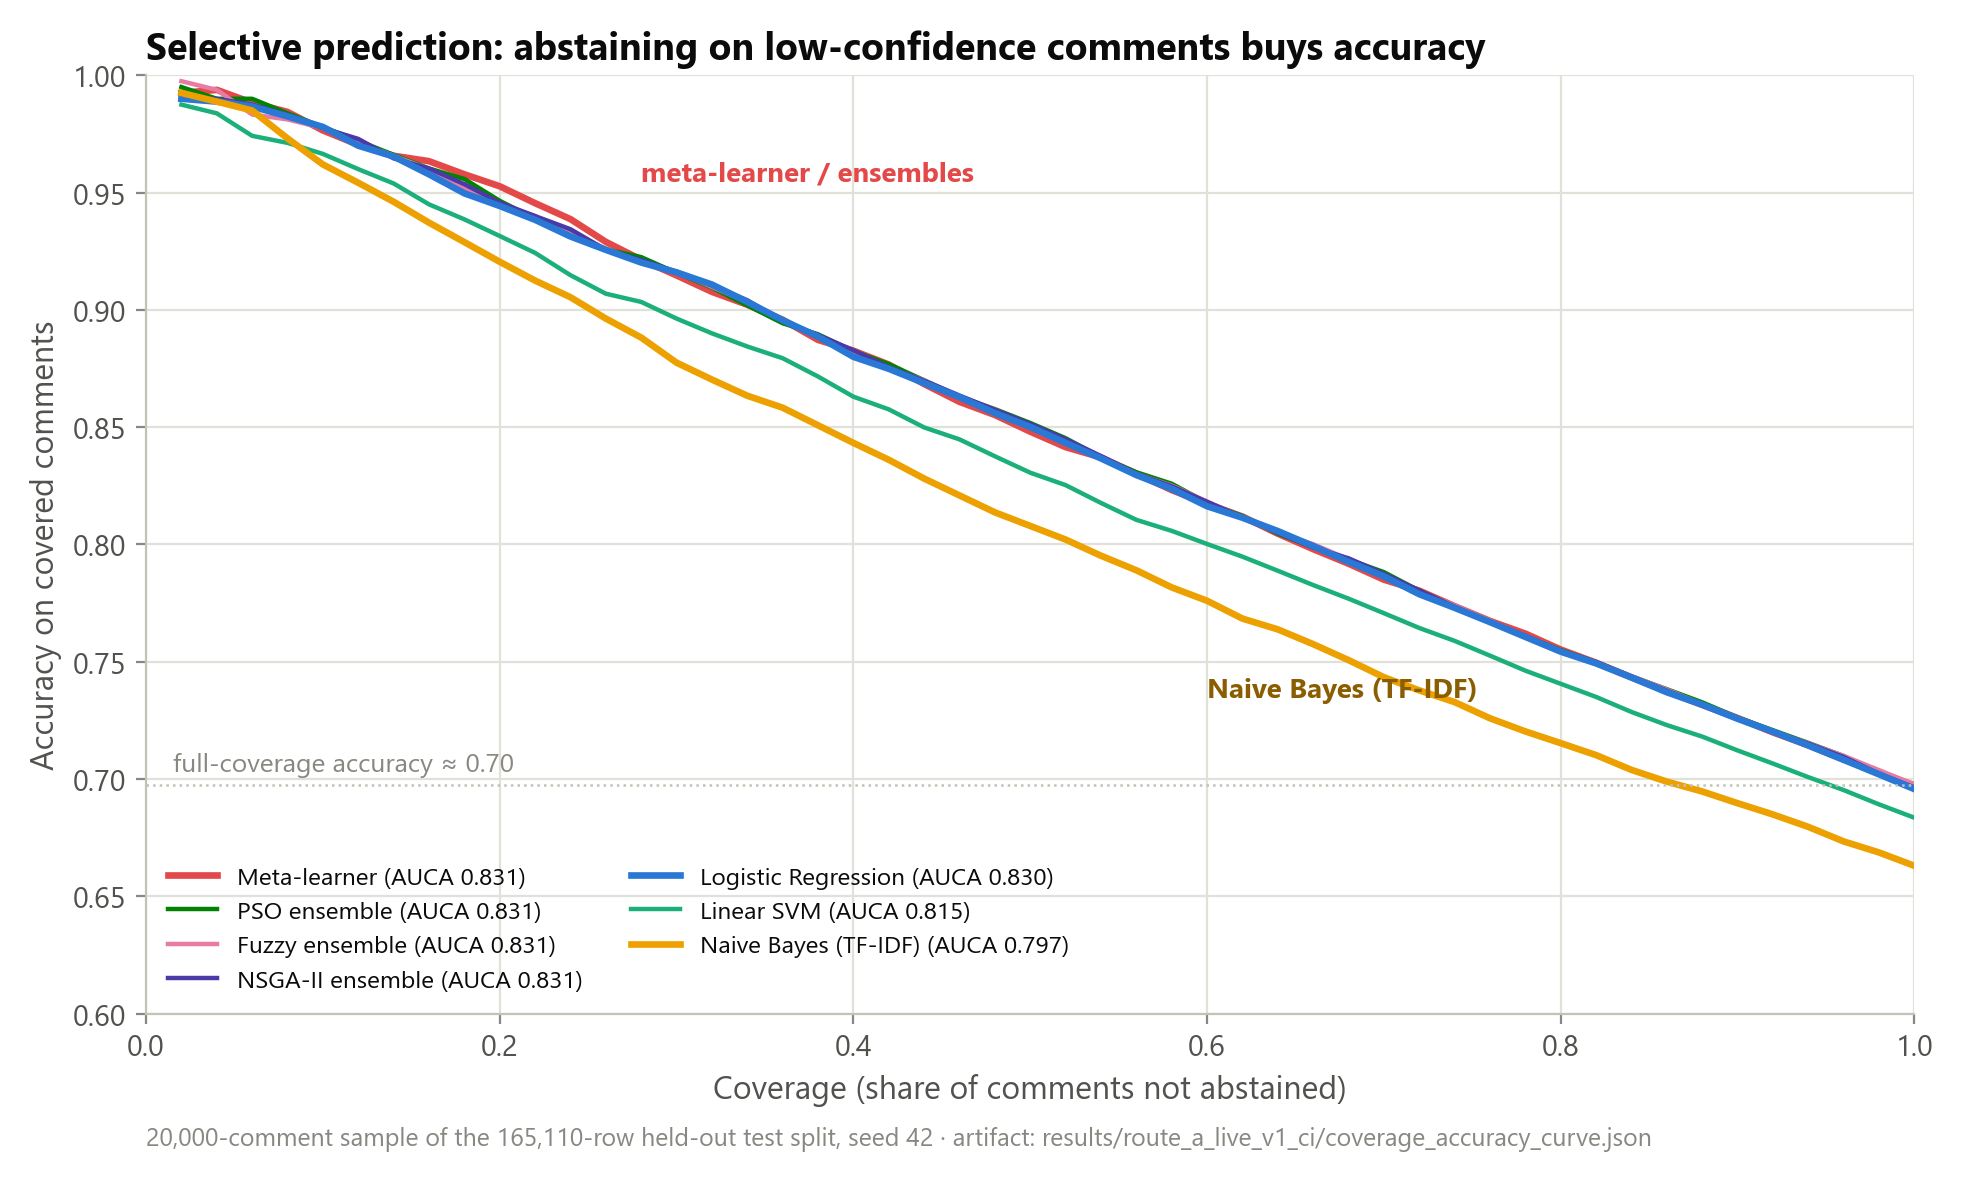

In [11]:
show_thesis_fig('fig_coverage_accuracy.png')

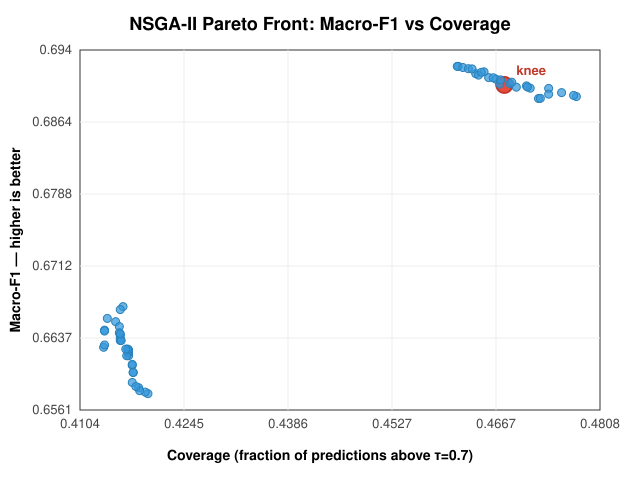

In [12]:
show_fig('pareto_f1_vs_coverage.svg', root=RESULTS)

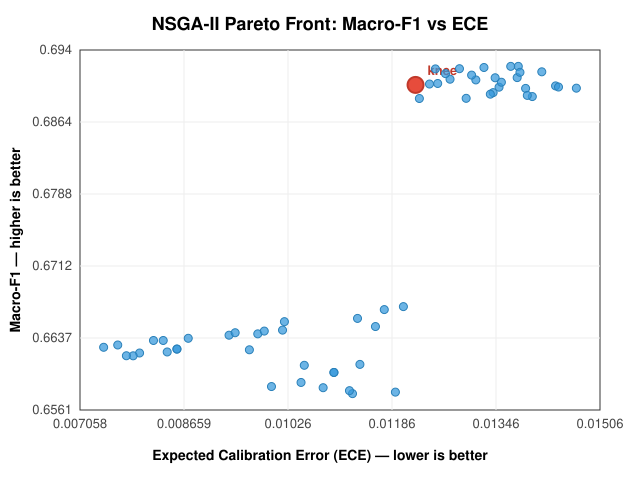

In [13]:
show_fig('pareto_f1_vs_ece.svg', root=RESULTS)

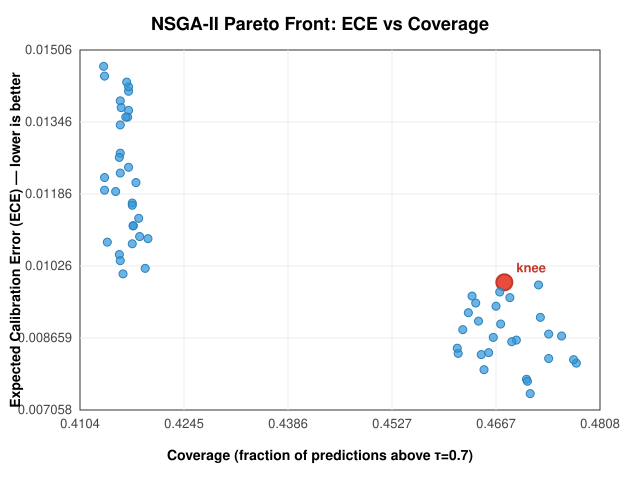

In [14]:
show_fig('pareto_ece_vs_coverage.svg', root=RESULTS)

## Notes

*(Add your own framing here: which comparisons are statistically significant at alpha=0.05 after correction, and which apparent improvements are not — this is usually the first thing examiners probe.)*